# Camões - Rocket Experiment Division 

Launched at EUROC'23, achieved the target apogee of 3000 meters, with a flawless ascent phase, featuring effective air brake operation throughout. 
The recovery phase had only the actuation of a drogue parachute.

Permission to use flight data given by Gonçalo Machado, 2024.

These results were extracted out of the flight card:

1. Team number: `20`
2. Launch date: `October 14th, 2023. 14h local time`
3. Simulated apogee: `3003 m`
4. Official recorded apogee: `3015 m`

The relative error of altitude apogee is only `0.39%`!

In [61]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [62]:
import matplotlib.pyplot as plt

from rocketpy import (
    Environment,
    Flight,
    Function,
    Rocket,
    SolidMotor,
)

plt.style.use("seaborn-v0_8-colorblind")

## Environment


Gravity Details

Acceleration of gravity at surface level:    9.8066 m/s²
Acceleration of gravity at   4.000 km (ASL): 9.8066 m/s²


Launch Site Details

Launch Date: 2023-10-14 13:00:00 UTC | 2023-10-14 14:00:00 Portugal
Launch Site Latitude: 39.39000°
Launch Site Longitude: -8.28954°
Reference Datum: WGS84
Launch Site UTM coordinates: 44367.90 W    4373424.89 N
Launch Site UTM zone: 30S
Launch Site Surface Elevation: 107.0 m


Atmospheric Model Details

Atmospheric Model Type: standard_atmosphere
standard_atmosphere Maximum Height: 4.000 km

Surface Atmospheric Conditions

Surface Wind Speed: 0.00 m/s
Surface Wind Direction: 0.00°
Surface Wind Heading: 0.00°
Surface Pressure: 1000.69 hPa
Surface Temperature: 287.46 K
Surface Air Density: 1.213 kg/m³
Surface Speed of Sound: 339.85 m/s


Earth Model Details

Earth Radius at Launch site: 6369.57 km
Semi-major Axis: 6378.14 km
Semi-minor Axis: 6356.75 km
Flattening: 0.0034


Atmospheric Model Plots



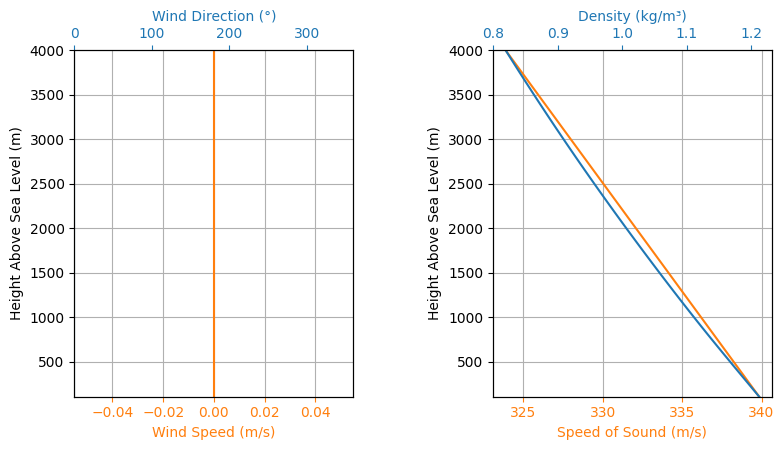

In [ ]:
env = Environment(
    gravity=9.80665,
    date=(2023, 10, 14, 14),
    latitude=39.3900032043457,
    longitude=-8.2895383834838,
    elevation=107,
    datum="WGS84",
    timezone="Portugal",
)

env.set_atmospheric_model(
    type="Reanalysis",
    file="../../data/weather/euroc_2023_all_windows.nc",
    dictionary="ECMWF",
)
env.max_expected_height = 4000
env.info()

## Motor

In [64]:
Mariachi = SolidMotor(
    thrust_source="../../data/rockets/camoes/thrust_source.csv",
    burn_time=3.72,
    grain_number=6,
    grain_density=1637,
    grain_initial_inner_radius=0.015,
    grain_outer_radius=0.045,
    grain_initial_height=0.15,
    nozzle_radius=0.034,
    throat_radius=0.0135,
    grain_separation=0.005,
    grains_center_of_mass_position=-0.7566,
    dry_inertia=(0, 0, 0),
    center_of_dry_mass_position=0,
    dry_mass=0,
    nozzle_position=-1.3346,
)

Nozzle Details
Nozzle Radius: 0.034 m
Nozzle Throat Radius: 0.0135 m

Grain Details
Number of Grains: 6
Grain Spacing: 0.005 m
Grain Density: 1637 kg/m3
Grain Outer Radius: 0.045 m
Grain Inner Radius: 0.015 m
Grain Height: 0.15 m
Grain Volume: 0.001 m3
Grain Mass: 1.389 kg

Motor Details
Total Burning Time: 3.72 s
Total Propellant Mass: 8.331 kg
Structural Mass Ratio: 0.000
Average Propellant Exhaust Velocity: 1320.764 m/s
Average Thrust: 2957.984 N
Maximum Thrust: 4145.791 N at 1.65 s after ignition.
Total Impulse: 11003.702 Ns



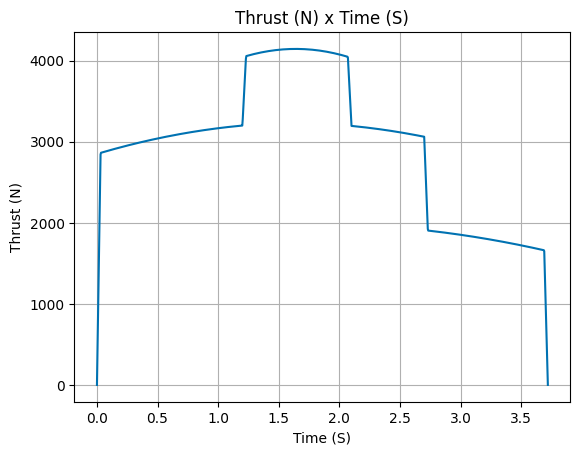

In [65]:
Mariachi.info()

## Rocket and Aerodynamic surfaces

For comparison purposes, no parachute will be added to the simulation

In [66]:
CAMOES = Rocket(
    radius=0.0715,
    mass=22.8,
    inertia=(16.2, 16.2, 0.066),
    center_of_mass_without_motor=0,
    power_off_drag="../../data/rockets/camoes/drag_coefficient_power_off.csv",
    power_on_drag="../../data/rockets/camoes/drag_coefficient_power_on.csv",
    coordinate_system_orientation="tail_to_nose",
)

CAMOES.set_rail_buttons(0.5, 0.2)

CAMOES.add_motor(Mariachi, position=0)

In [67]:
NoseCone = CAMOES.add_nose(
    length=0.455,
    kind="vonKarman",
    position=1.1884,
)

FinSet = CAMOES.add_trapezoidal_fins(
    n=4,
    span=0.155,
    root_chord=0.185,
    tip_chord=0.15,
    position=-1.0866,
)

Tail = CAMOES.add_tail(
    top_radius=0.0715, bottom_radius=0.037, length=0.048, position=-1.2866
)

In [68]:
def drogue_trigger(**kwargs):
    state = kwargs["state"]
    return True if state[5] < 5 and state[2] > 300 else False


Drogue = CAMOES.add_parachute(
    "Drogue", cd_s=0.33, sampling_rate=400, lag=1.5, trigger=drogue_trigger
)

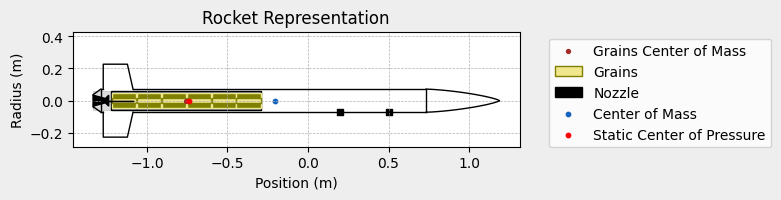

In [69]:
CAMOES.draw()

## Air Brakes - Active Control Systems

For privacy reasons, the controller function is not the one developed and used by the team. 

The controller function just describes the actuation with time of the algorithm developed by the team. 

In [70]:
import numpy as np


def controller_function(**kwargs):
    time = kwargs["time"]
    air_brakes = kwargs["air_brakes"]

    new_deployment_level = 0

    if time <= 11.4:
        new_deployment_level = 1
    else:
        new_deployment_level = (
            -0.002906 * np.power(time, 3)
            + 0.1497 * np.power(time, 2)
            + -2.563 * time
            + 14.96
        )

    if time > 19.6:
        new_deployment_level = 0

    if time < 3.8:
        new_deployment_level = 0

    air_brakes.deployment_level = new_deployment_level

    return time, air_brakes.deployment_level


In [71]:
air_brakes = CAMOES.add_air_brakes(
    drag_coefficient_curve=[
        # Mach 0.1
        [0, 0.1, 0.7692],
        [10 / 100, 0.1, 0.7663],
        [20 / 100, 0.1, 0.7762],
        [30 / 100, 0.1, 0.7847],
        [40 / 100, 0.1, 0.7999],
        [50 / 100, 0.1, 0.8246],
        [60 / 100, 0.1, 0.8310],
        [70 / 100, 0.1, 0.8499],
        [80 / 100, 0.1, 0.8738],
        [90 / 100, 0.1, 0.8945],
        [100 / 100, 0.1, 1.1018],
        # Mach 0.2
        [0, 0.2, 0.7508],
        [10 / 100, 0.2, 0.7513],
        [20 / 100, 0.2, 0.7670],
        [30 / 100, 0.2, 0.7782],
        [40 / 100, 0.2, 0.7943],
        [50 / 100, 0.2, 0.8063],
        [60 / 100, 0.2, 0.8243],
        [70 / 100, 0.2, 0.8493],
        [80 / 100, 0.2, 0.8781],
        [90 / 100, 0.2, 0.8925],
        [100 / 100, 0.2, 0.9851],
        # Mach 0.3
        [0, 0.3, 0.7445],
        [10 / 100, 0.3, 0.7571],
        [20 / 100, 0.3, 0.7699],
        [30 / 100, 0.3, 0.7828],
        [40 / 100, 0.3, 0.7985],
        [50 / 100, 0.3, 0.8114],
        [60 / 100, 0.3, 0.8379],
        [70 / 100, 0.3, 0.8634],
        [80 / 100, 0.3, 0.8834],
        [90 / 100, 0.3, 0.8947],
        [100 / 100, 0.3, 0.9782],
        # Mach 0.4
        [0, 0.4, 0.7492],
        [10 / 100, 0.4, 0.7566],
        [20 / 100, 0.4, 0.7698],
        [30 / 100, 0.4, 0.7840],
        [40 / 100, 0.4, 0.7994],
        [50 / 100, 0.4, 0.8136],
        [60 / 100, 0.4, 0.8399],
        [70 / 100, 0.4, 0.8665],
        [80 / 100, 0.4, 0.8834],
        [90 / 100, 0.4, 0.8969],
        [100 / 100, 0.4, 0.9659],
        # Mach 0.5
        [0, 0.5, 0.7454],
        [10 / 100, 0.5, 0.7537],
        [20 / 100, 0.5, 0.7651],
        [30 / 100, 0.5, 0.7811],
        [40 / 100, 0.5, 0.7987],
        [50 / 100, 0.5, 0.8163],
        [60 / 100, 0.5, 0.8404],
        [70 / 100, 0.5, 0.8631],
        [80 / 100, 0.5, 0.8788],
        [90 / 100, 0.5, 0.8951],
        [100 / 100, 0.5, 0.9416],
        # Mach 0.6
        [0, 0.6, 0.7036],
        [10 / 100, 0.6, 0.7237],
        [20 / 100, 0.6, 0.7359],
        [30 / 100, 0.6, 0.7496],
        [40 / 100, 0.6, 0.7684],
        [50 / 100, 0.6, 0.7899],
        [60 / 100, 0.6, 0.8153],
        [70 / 100, 0.6, 0.8406],
        [80 / 100, 0.6, 0.8539],
        [90 / 100, 0.6, 0.8712],
        [100 / 100, 0.6, 0.9286],
        # Mach 0.7
        [0, 0.7, 0.6810],
        [10 / 100, 0.7, 0.6948],
        [20 / 100, 0.7, 0.7076],
        [30 / 100, 0.7, 0.7233],
        [40 / 100, 0.7, 0.7427],
        [50 / 100, 0.7, 0.7629],
        [60 / 100, 0.7, 0.7876],
        [70 / 100, 0.7, 0.8073],
        [80 / 100, 0.7, 0.8272],
        [90 / 100, 0.7, 0.8453],
        [100 / 100, 0.7, 0.8960],
        # Mach 0.8
        [0, 0.8, 0.6578],
        [10 / 100, 0.8, 0.6739],
        [20 / 100, 0.8, 0.6870],
        [30 / 100, 0.8, 0.7036],
        [40 / 100, 0.8, 0.7240],
        [50 / 100, 0.8, 0.7457],
        [60 / 100, 0.8, 0.7676],
        [70 / 100, 0.8, 0.7880],
        [80 / 100, 0.8, 0.8098],
        [90 / 100, 0.8, 0.8278],
        [100 / 100, 0.8, 0.8799],
        # Mach 0.9
        [0, 0.9, 0.6574],
        [10 / 100, 0.9, 0.6634],
        [20 / 100, 0.9, 0.6794],
        [30 / 100, 0.9, 0.6958],
        [40 / 100, 0.9, 0.7201],
        [50 / 100, 0.9, 0.7395],
        [60 / 100, 0.9, 0.7618],
        [70 / 100, 0.9, 0.7844],
        [80 / 100, 0.9, 0.8057],
        [90 / 100, 0.9, 0.8278],
        [100 / 100, 0.9, 0.8628],
        # Mach 1.0
        [0, 1.0, 0.8350],
        [10 / 100, 1.0, 0.8241],
        [20 / 100, 1.0, 0.8403],
        [30 / 100, 1.0, 0.8593],
        [40 / 100, 1.0, 0.8832],
        [50 / 100, 1.0, 0.9070],
        [60 / 100, 1.0, 0.9358],
        [70 / 100, 1.0, 0.9639],
        [80 / 100, 1.0, 0.9881],
        [90 / 100, 1.0, 1.0093],
        [100 / 100, 1.0, 1.0347],
        # Mach 1.1
        [0, 1.1, 0.8610],
        [10 / 100, 1.1, 0.8447],
        [20 / 100, 1.1, 0.8617],
        [30 / 100, 1.1, 0.8800],
        [40 / 100, 1.1, 0.9027],
        [50 / 100, 1.1, 0.9244],
        [60 / 100, 1.1, 0.9515],
        [70 / 100, 1.1, 0.9810],
        [80 / 100, 1.1, 1.0069],
        [90 / 100, 1.1, 1.0253],
        [100 / 100, 1.1, 1.0560],
    ],
    controller_function=controller_function,
    sampling_rate=10,
    reference_area=None,
    clamp=True,
    initial_observed_variables=(0, 0),
    override_rocket_drag=True,
    name="Air Brakes",
)

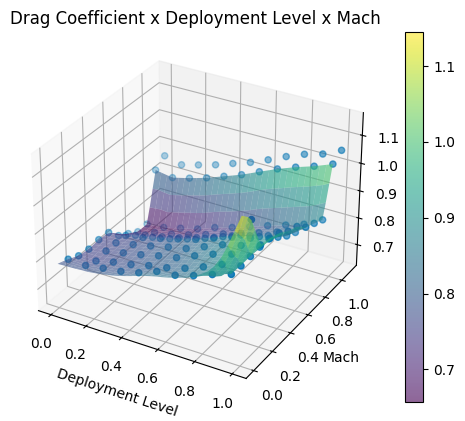

In [72]:
air_brakes.all_info()

## Flight Simulation Data

In [73]:
test_flight = Flight(
    rocket=CAMOES, environment=env, inclination=84, heading=133, rail_length=12
)


Apogee State

Apogee Time: 24.209 s
Apogee Altitude: 3090.224 m (ASL) | 2983.224 m (AGL)
Apogee Freestream Speed: 17.674 m/s
Apogee X position: 403.076 m
Apogee Y position: -380.423 m
Apogee latitude: 39.3865811°
Apogee longitude: -8.2848472°


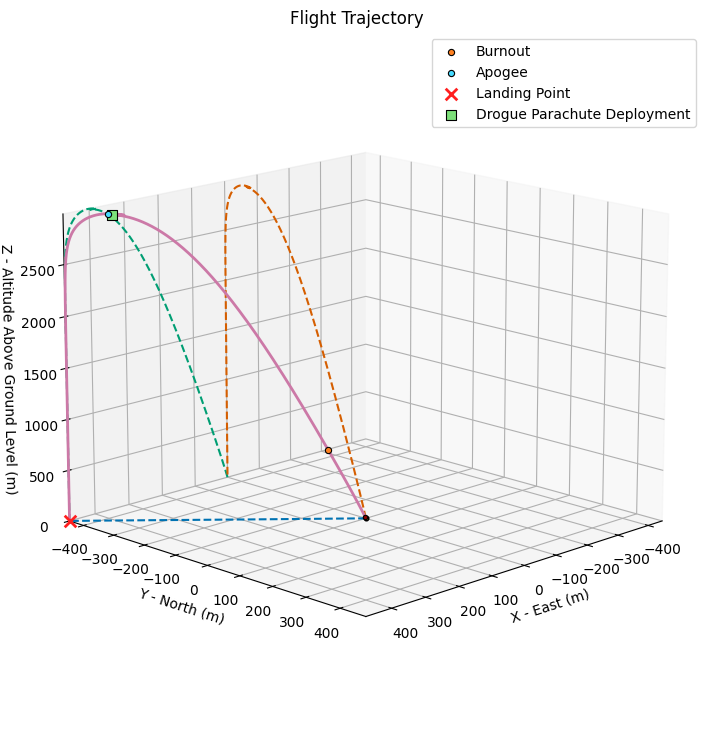

In [74]:
test_flight.prints.apogee_conditions()
test_flight.plots.trajectory_3d()

## Airbrakes actuation analysis

/tmp/ipykernel_41946/613100350.py:5: DeprecationWarning: Controller observed variables are no longer supported. and will be removed in v1.13.0. Use `Access the desired variables via controller.log` instead.
  obs_vars = test_flight.get_controller_observed_variables()


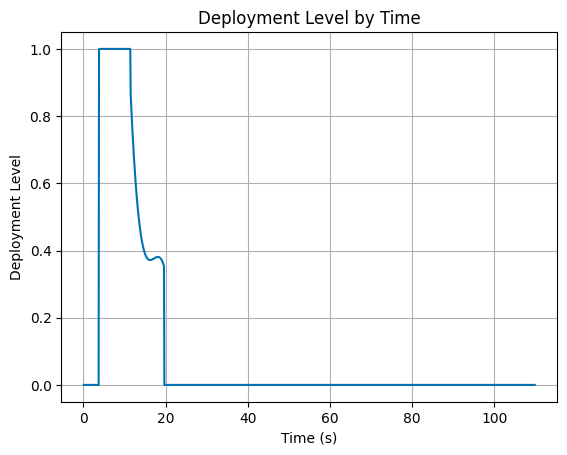

In [75]:
import matplotlib.pyplot as plt

time_list, deployment_level_list = [], []

obs_vars = test_flight.get_controller_observed_variables()

for time, deployment_level in obs_vars:
    time_list.append(time)
    deployment_level_list.append(deployment_level)

# Plot deployment level by time
plt.plot(time_list, deployment_level_list)
plt.xlabel("Time (s)")
plt.ylabel("Deployment Level")
plt.title("Deployment Level by Time")
plt.grid()
plt.show()

## Data analysis

In [76]:
from rocketpy.simulation.flight_data_importer import FlightDataImporter

In [77]:
columns_map = {
    "ts": "time",
    "filtered_altitude_AGL": "altitude",
    "filtered_acceleration": "az",
}

cots_altimeter_flight = FlightDataImporter(
    name="COTS Altimeter Flight",
    paths="../../data/rockets/camoes/flight_data.csv",
    columns_map=columns_map,
    units=None,
    interpolation="linear",
    extrapolation="zero",
    delimiter=",",
    encoding="utf-8",
)

The following attributes were create and are now available to be used:  ['time', 'altitude', 'az']


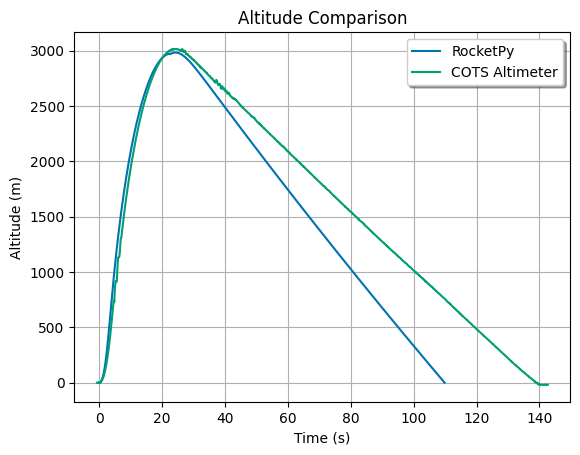

In [78]:
Function.compare_plots(
    [
        (test_flight.altitude, "RocketPy"),
        (cots_altimeter_flight.altitude, "COTS Altimeter"),
    ],
    title="Altitude Comparison",
    xlabel="Time (s)",
    ylabel="Altitude (m)",
)

In [79]:
columns_map = {
    "ts": "time",
    "latitude": "latitude",
    "longitude": "longitude",
}

cots_gnss_flight = FlightDataImporter(
    name="COTS GNSS Flight",
    paths="../../data/rockets/camoes/gnss_flight.csv",
    columns_map=columns_map,
    units=None,
    interpolation="linear",
    extrapolation="zero",
    delimiter=",",
    encoding="utf-8",
)

The following attributes were create and are now available to be used:  ['time', 'latitude', 'longitude']


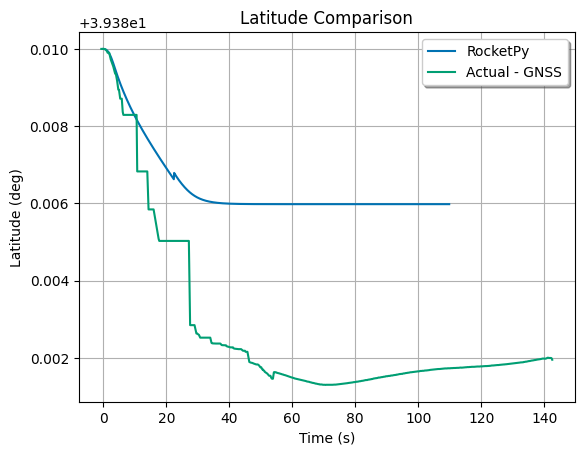

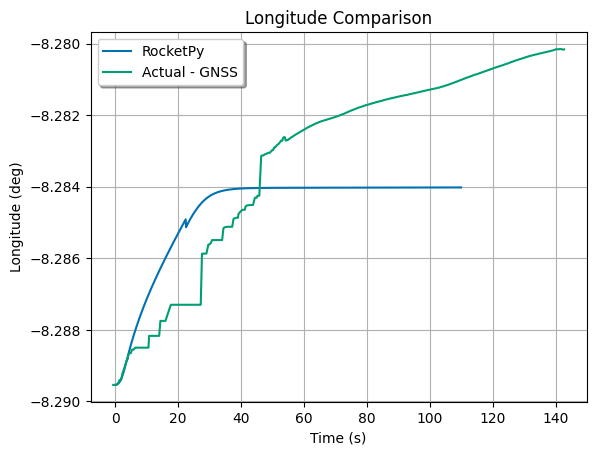

In [80]:
Function.compare_plots(
    [(test_flight.latitude, "RocketPy"), (cots_gnss_flight.latitude, "Actual - GNSS")],
    title="Latitude Comparison",
    xlabel="Time (s)",
    ylabel="Latitude (deg)",
)
Function.compare_plots(
    [
        (test_flight.longitude, "RocketPy"),
        (cots_gnss_flight.longitude, "Actual - GNSS"),
    ],
    title="Longitude Comparison",
    xlabel="Time (s)",
    ylabel="Longitude (deg)",
)